In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import os
from lmfit import Model
import random
import math
# import statsmodels
import statsmodels.formula.api as smf
from plotnine  import * 


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import forestci as fci
# from scipy.stats import t

from quantile_forest import RandomForestQuantileRegressor

# %matplotlib inline



In [81]:
# Read in input file

path = '/home/mgabr001/BrainGenix/BrainEmulationChallenge/src/models/autoassociative/NetmorphParOptim'
os.chdir(path)

df1 = pd.read_excel(open('ParameterSpace_700_samples-labeled.xlsx','rb'))    

print(df1.shape)
print(df1.columns)



(700, 9)
Index(['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight', 'usable_conns1',
       'usable_conns2'],
      dtype='str')


In [82]:
# Select Only Needed Columns

columnsA = ['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight', 'usable_conns1',
       'usable_conns2']


columnsB = ['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight','usable_conns2']


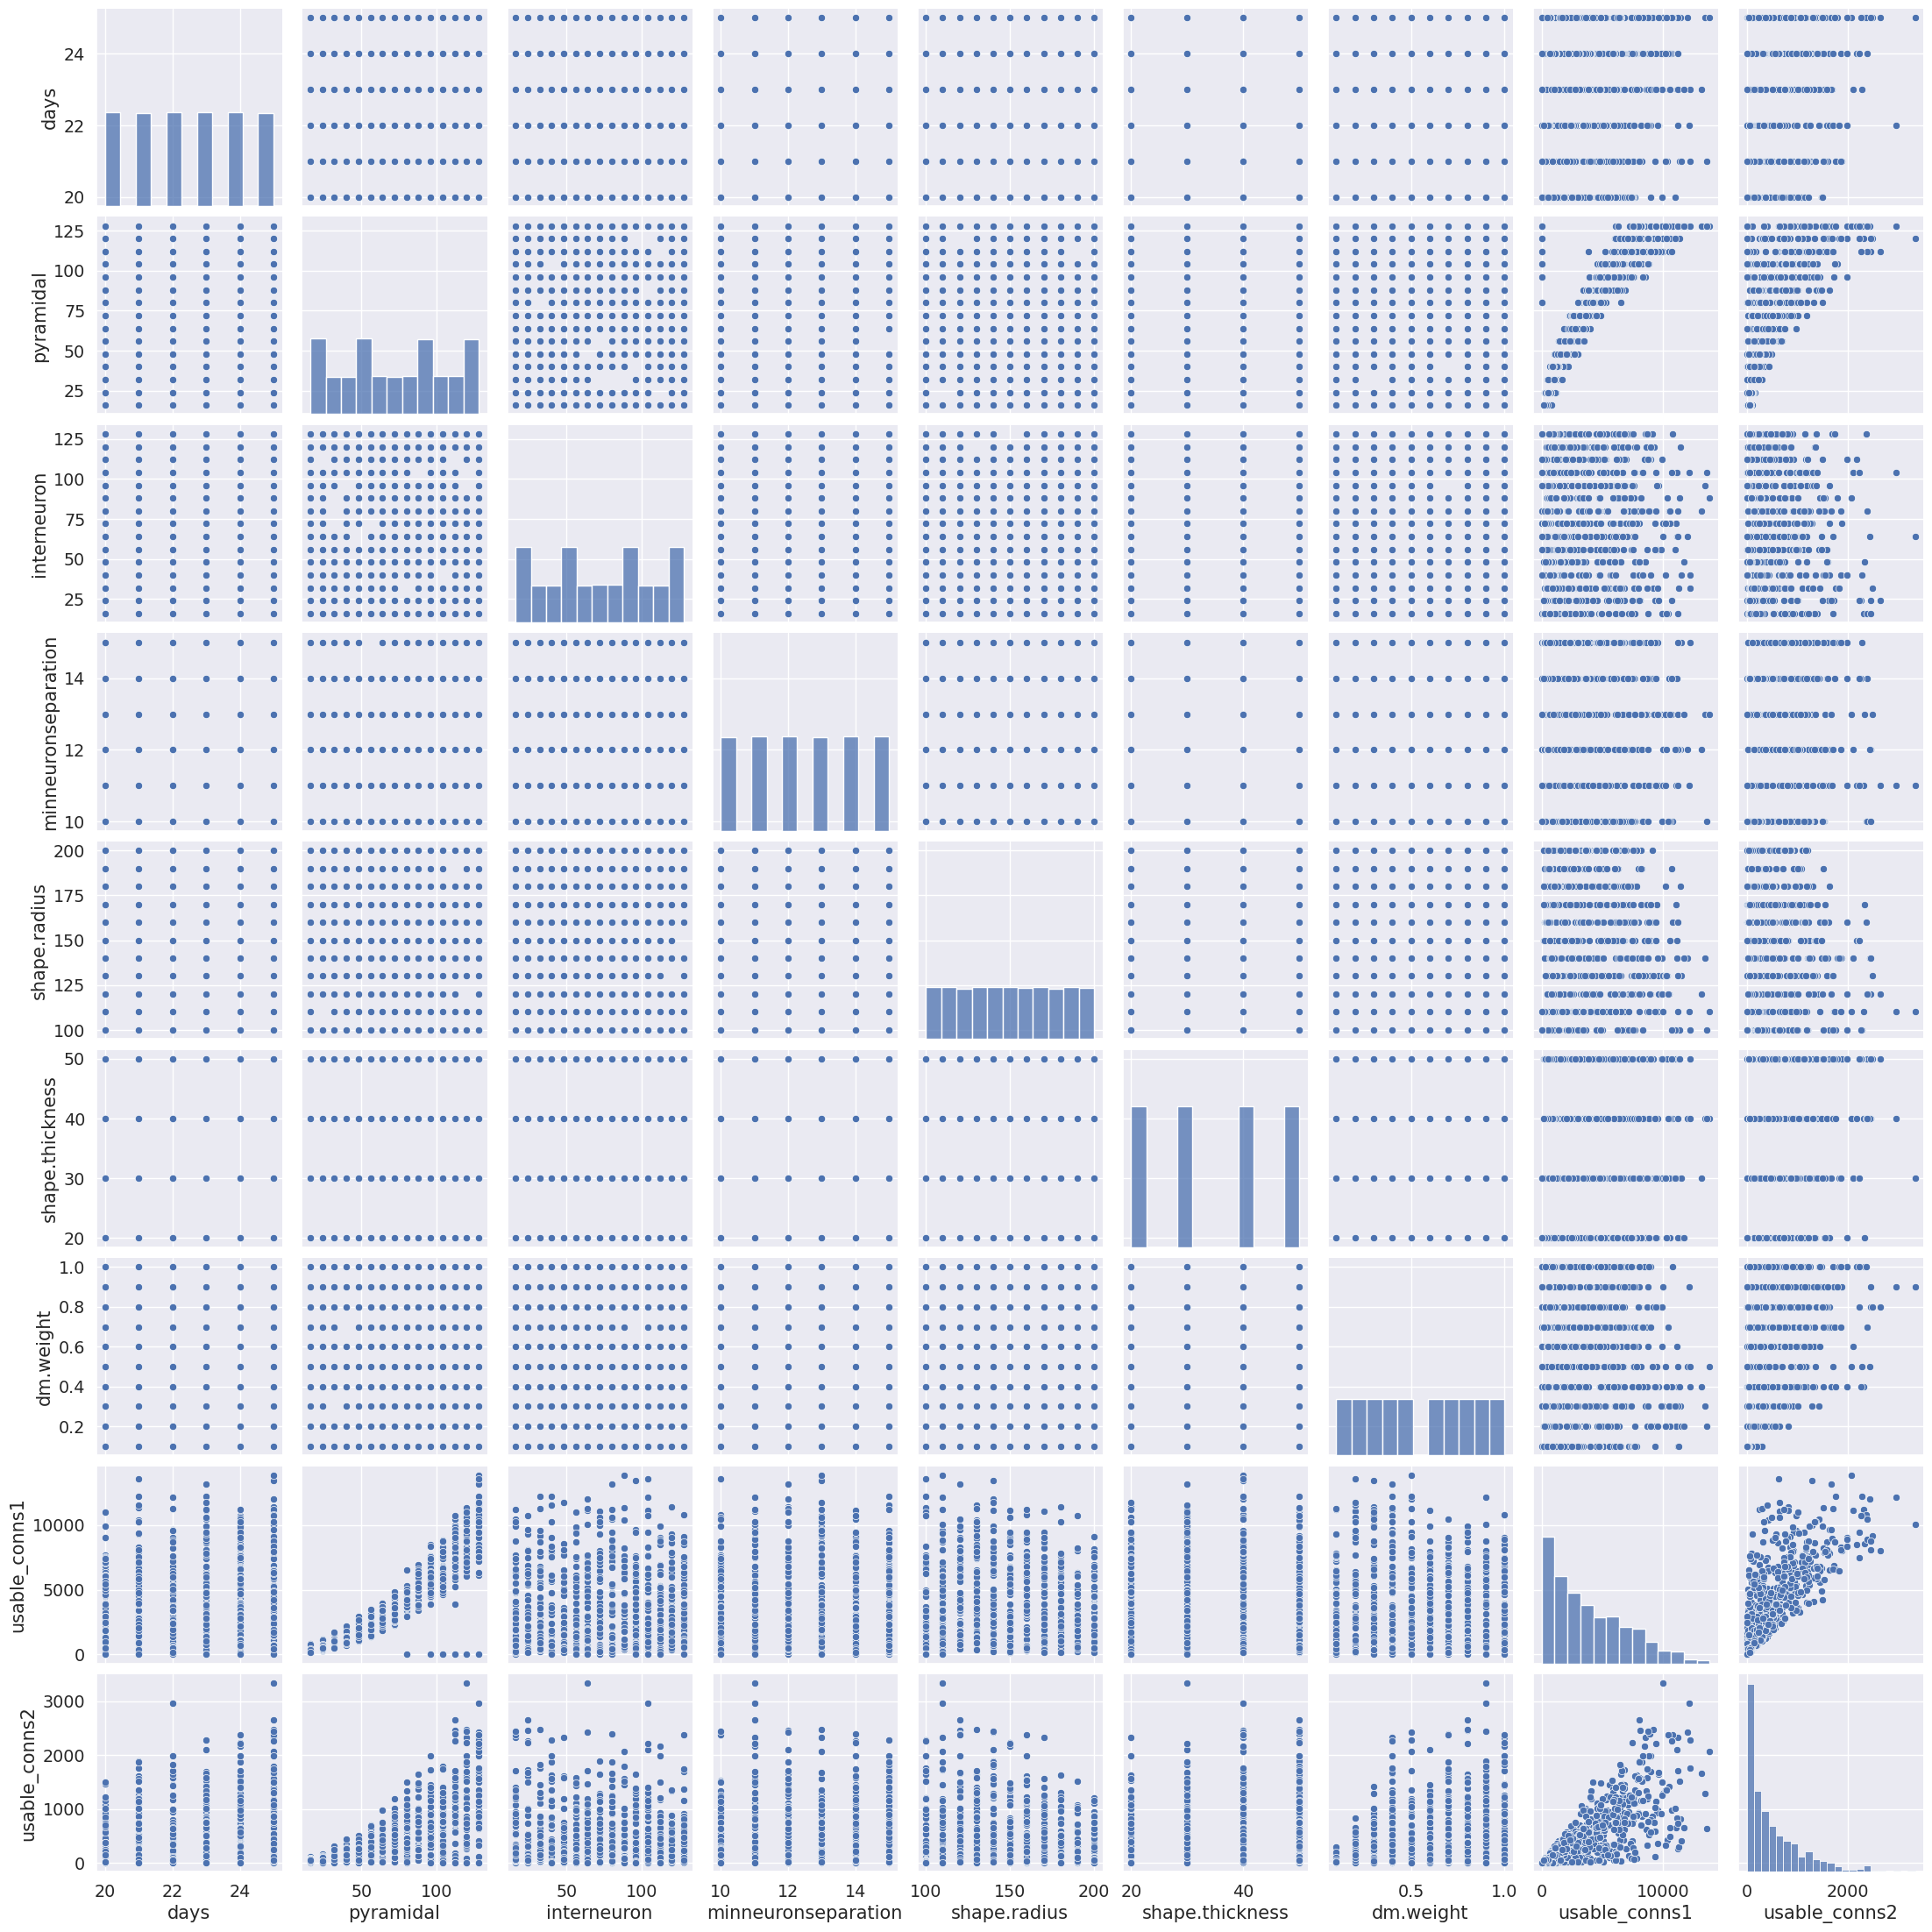

In [83]:
sns.pairplot(df1[columnsA], size = 2.5)
plt.show();

In [84]:
# sns.pairplot(df1[columnsB], size = 2.5)
# plt.show();

In [85]:

# #correlation matrix
# corrmat = df1[columnsA].corr()
# f, ax = plt.subplots(figsize=(9, 6))
# sns.heatmap(corrmat, vmax=.8, square=True);

In [86]:
# # correlation matrix
# f, ax = plt.subplots(figsize=(9, 6))
# k = 10 #number of variables for heatmap
# corrmat = df1[columnsA].corr()
# cols = corrmat.nlargest(k, 'usable_conns1')['usable_conns1'].index
# cm = np.corrcoef(df1[cols].values.T)
# sns.set(font_scale=1.25)
# hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
# plt.show()
# f.savefig('Correlation_Matrix.png')

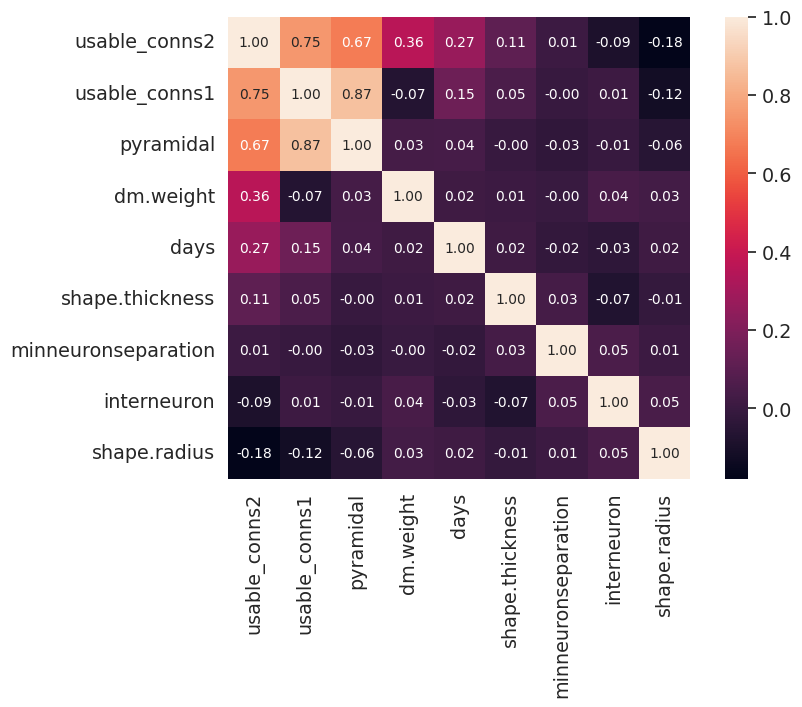

In [87]:

# correlation matrix
f, ax = plt.subplots(figsize=(9, 6))
k = 10 #number of variables for heatmap
corrmat = df1[columnsA].corr()
cols = corrmat.nlargest(k, 'usable_conns2')['usable_conns2'].index
cm = np.corrcoef(df1[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()
f.savefig('Correlation_Matrix.png')

## Creating Full Grid: Method 1


In [88]:
# Generate the FULL parameter Space

days = np.arange(20, 26, 1)                         # 6
pyramidal= np.arange(16, 136, 8)                    # 15        
interneuron = np.arange(16, 136, 8)                 # 15
minneuronseparation = np.arange(10, 16, 1)          # 6
shape_radius = np.arange(100, 210, 10)              # 11  
shape_thickness = np.arange(20, 60, 10)             # 4
dm_weight = np.arange(0.1, 1.1, 0.1)                # 10

ldays = len(days)
lpyramidal = len(pyramidal)
linterneuron = len(interneuron)     
lminneuronseparation = len(minneuronseparation)
lshape_radius = len(shape_radius)
lshape_thickness = len(shape_thickness)
ldm_weight = len(dm_weight) 




In [89]:
# N = ldays * lpyramidal * linterneuron * lminneuronseparation * lshape_radius * lshape_thickness * ldm_weight
# print("N = ", N)
# #full grid
# arr=[(N,9)]

# for i in range(ldays):
#     for j in range(lpyramidal):
#         for k in range(linterneuron):
#             for l in range(lminneuronseparation):
#                 for m in range(lshape_radius):
#                     for n in range(lshape_thickness):
#                        for ii in range(ldm_weight):
                         
#                                 arr.append([ days[i], pyramidal[j], interneuron[k], minneuronseparation[l], shape_radius[m], shape_thickness[n], dm_weight[ii] ])
#                                 #######  When created this way, the first row of the arr is the total # of rows and needs to be dropped when creating the prediction grid.
#                                 #print([ days[i], pyramidal[j], interneuron[k], minneuronseparation[l], shape_radius[m], shape_thickness[n], dm_weight[ii]])




#######  When created this way, the first row should not be dropped when creating the prediction grid.

# arr = [[ NumLevels[i], ScrewDiam[j], ScrewLen[k], CenterlineWidth[l],Hooks[m],OPlate[n],OScrewDiam[ii],OScrewLen[jj], None] \
#     for i in range(lNumLevels) \
#     for j in range(lScrewDiam) \
#     for k in range(lScrewLen) \
#     for l in range(lCenterlineWidth) \
#     for m in range(lHooks) \
#     for n in range(lOPlate) \
#     for ii in range(lOScrewDiam) \
#     for jj in range(lOScrewLen)]

## Creating Full Grid: Method 2

In [90]:
N = ldays * lpyramidal * linterneuron * lminneuronseparation * lshape_radius * lshape_thickness * ldm_weight
print("N = ", N)
#full grid
arr=[(N,9)]

#######  When created this way, the first row should not be dropped when creating the prediction grid.

arr = [[ days[i], pyramidal[j], interneuron[k], minneuronseparation[l], shape_radius[m], shape_thickness[n], dm_weight[ii] ] \
    for i in range(ldays) \
    for j in range(lpyramidal) \
    for k in range(linterneuron) \
    for l in range(lminneuronseparation) \
    for m in range(lshape_radius) \
    for n in range(lshape_thickness) \
    for ii in range(ldm_weight)]
  

N =  3564000


In [91]:
print("Length of arr:", len(arr))

Length of arr: 3564000


In [92]:
print(arr[:2 :])

[[np.int64(20), np.int64(16), np.int64(16), np.int64(10), np.int64(100), np.int64(20), np.float64(0.1)], [np.int64(20), np.int64(16), np.int64(16), np.int64(10), np.int64(100), np.int64(20), np.float64(0.2)]]


# Create a prediction array for the entire parameter space

In [93]:
# Create a prediction array for the entire parameter space

clms = ['days', 'pyramidal', 'interneuron', 'minneuronseparation','shape.radius', 'shape.thickness', 'dm.weight']

pred_grid = pd.DataFrame(data = arr, columns = clms)

pred_grid.drop_duplicates(keep='first', inplace=True)
# pred_grid = pred_grid.iloc[1:]  # drop the first row. 1st row is the total # rows and columns 
pred_grid.shape


(3564000, 7)

## Create Training and Test datasets: split 80% and 20%

In [94]:
cols = ['days', 
        'pyramidal', 
        'interneuron', 
        'minneuronseparation',
        'shape.radius', 
        'shape.thickness', 
        'dm.weight'
        ]

X_train, X_test, y_train, y_test = train_test_split(df1[cols],df1['usable_conns2'], test_size=0.2, random_state=27)
X_train.shape

(560, 7)

In [95]:
print(X_train.head())
# print(y_train.head()) 

     days  pyramidal  interneuron  minneuronseparation  shape.radius  \
623    22         48           72                   11           160   
372    20         48           40                   14           190   
246    22         64           16                   13           160   
38     21         88          128                   14           200   
562    24        104           32                   15           180   

     shape.thickness  dm.weight  
623               30        0.5  
372               20        0.9  
246               50        0.8  
38                40        0.6  
562               40        0.8  


# Random Forest Regression

In [96]:
clf1 = RandomForestRegressor(n_estimators=1000, bootstrap = True, oob_score = True)


# train the model
clf1.fit(X_train, y_train)

print('Fit R2 = ', clf1.score(X_train, y_train))

# predict on training data
X_train['Pred_usable_conns2'] = clf1.predict(X_train)

resid1 = y_train - clf1.oob_prediction_


# 95% prediction interval of the training set  # 95% confidence limits on individual predictions
lowq = resid1.quantile(0.025)
highq = resid1.quantile(0.975)
print(("Lower Quantile: ", lowq, "   Upper Quantile: ", highq)) 

X_train['Lower'] = (X_train['Pred_usable_conns2']+lowq).clip(0)
X_train['Upper'] = X_train['Pred_usable_conns2']+highq


# Relative Difference of the Simulated and Predicted Usable Connections2 in %.
relDiff1 = 100 * abs((y_train - X_train['Pred_usable_conns2'])/y_train)

X_train['Relative_percent_diff'] = relDiff1


# #### 
# with pd.ExcelWriter("Phase1-_predictions.xlsx") as writer:
#     df1.to_excel(writer, index=False)  




# Predict on Phase 3 data (Test data)
X_test['Pred_usable_conns2'] = clf1.predict(X_test)

# Prediction Intervals for the Test data
lowq_test = (X_test['Pred_usable_conns2'] + lowq).clip(0) #cant have negative numbers
highq_test = (X_test['Pred_usable_conns2'] + highq)

print(("Lower Quantile (Test): ", lowq_test, "   Upper Quantile (Test): ", highq_test))

cover_test = (X_test['Pred_usable_conns2'] >= lowq_test) & (X_test['Pred_usable_conns2'] <= highq_test)
print(cover_test.mean())


Fit R2 =  0.9748938914237171
('Lower Quantile: ', np.float64(-378.7137204618687), '   Upper Quantile: ', np.float64(483.10762770562593))
('Lower Quantile (Test): ', 113    1042.38428
596     101.20928
177       0.00000
473     941.93628
434      10.72428
          ...    
37      170.81428
377       0.00000
295     298.11328
420     557.36728
255     337.52828
Name: Pred_usable_conns2, Length: 140, dtype: float64, '   Upper Quantile (Test): ', 113    1904.205628
596     963.030628
177     559.483628
473    1803.757628
434     872.545628
          ...     
37     1032.635628
377     507.354628
295    1159.934628
420    1419.188628
255    1199.349628
Name: Pred_usable_conns2, Length: 140, dtype: float64)
1.0


In [97]:
X_train.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,Lower,Upper,Relative_percent_diff
623,22,48,72,11,160,30,0.5,206.514,0.00000,689.621628,7.002073
372,20,48,40,14,190,20,0.9,204.156,0.00000,687.263628,1.848077
246,22,64,16,13,160,50,0.8,496.139,117.42528,979.246628,4.771785
38,21,88,128,14,200,40,0.6,366.426,0.00000,849.533628,17.821865
562,24,104,32,15,180,40,0.8,1188.055,809.34128,1671.162628,2.458539


In [101]:

# Calculate the variance
# Notes
# The calculation of error is based on the infinitesimal jackknife variance, as described in [Wager2014] 
# and is a Python implementation of the R code provided at: https://github.com/swager/randomForestCI
# Wager2014
#    S. Wager, T. Hastie, B. Efron. “Confidence Intervals for Random Forests: 
# The Jackknife and the Infinitesimal Jackknife”, Journal of Machine Learning Research vol. 15, pp. 1625-1651, 2014.

# The basic idea of the jackknife is to omit one observation and recompute the estimate using the remaining observations. 
# This is done for each observation, and the results are then combined to produce a variance estimate or bias correction.


ci = fci.random_forest_error(
  forest=clf1, # scikit-learn Forest model fitted on X_train
  X_train_shape = X_train[cols].shape,
  X_test=X_test[cols], # the samples you want to compute the CI
  inbag=None,
  calibrate=True,
  memory_constrained=False,
  memory_limit=None,
  y_output=0 # in case of multioutput model, consider target 0
)


X_test['Pred_MaxT_Err'] = np.sqrt(ci)



In [102]:
print(" Mean Error +\- Std of Errors: ", X_test['Pred_MaxT_Err'].mean() ,"+\-", X_test['Pred_MaxT_Err'].std())

 Mean Error +\- Std of Errors:  77.19235981235522 +\- 53.99871245844115


### Predict Usable Connections for the entire parameter space using Best FIT model.

In [103]:

pred_grid['Pred_usable_conns2'] = clf1.predict(pred_grid[cols])
pred_grid['Lower'] = (pred_grid['Pred_usable_conns2']+lowq).clip(0)
pred_grid['Upper'] = pred_grid ['Pred_usable_conns2']+highq


In [104]:
pred_grid.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,Lower,Upper
0,20,16,16,10,100,20,0.1,17.680,0.0,500.787628
1,20,16,16,10,100,20,0.2,42.268,0.0,525.375628
2,20,16,16,10,100,20,0.3,60.039,0.0,543.146628
3,20,16,16,10,100,20,0.4,63.467,0.0,546.574628
4,20,16,16,10,100,20,0.5,63.582,0.0,546.689628


In [105]:

# Calculate the variance
# Notes
# The calculation of error is based on the infinitesimal jackknife variance, as described in [Wager2014] 
# and is a Python implementation of the R code provided at: https://github.com/swager/randomForestCI
# Wager2014
#    S. Wager, T. Hastie, B. Efron. “Confidence Intervals for Random Forests: 
# The Jackknife and the Infinitesimal Jackknife”, Journal of Machine Learning Research vol. 15, pp. 1625-1651, 2014.



ci_grid = fci.random_forest_error(
  forest=clf1, # scikit-learn Forest model fitted on X_train
  X_train_shape = X_train[cols].shape,
  X_test=pred_grid[cols], # the samples you want to compute the CI
  inbag=None,
  calibrate=True,
  memory_constrained=False,
  memory_limit=None,
  y_output=0 # in case of multioutput model, consider target 0
)


pred_grid['Pred_usable_conns2_Err'] = np.sqrt(ci_grid)



In [106]:
pred_grid.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,Lower,Upper,Pred_usable_conns2_Err
0,20,16,16,10,100,20,0.1,17.680,0.0,500.787628,59.283141
1,20,16,16,10,100,20,0.2,42.268,0.0,525.375628,59.370307
2,20,16,16,10,100,20,0.3,60.039,0.0,543.146628,59.347324
3,20,16,16,10,100,20,0.4,63.467,0.0,546.574628,59.360833
4,20,16,16,10,100,20,0.5,63.582,0.0,546.689628,59.379657


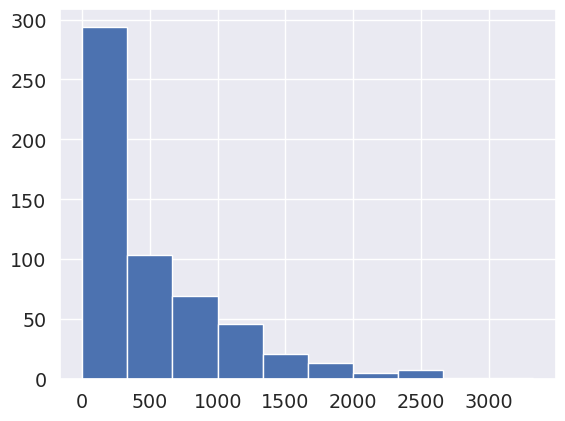

In [107]:
plt.hist(y_train)
plt.show()

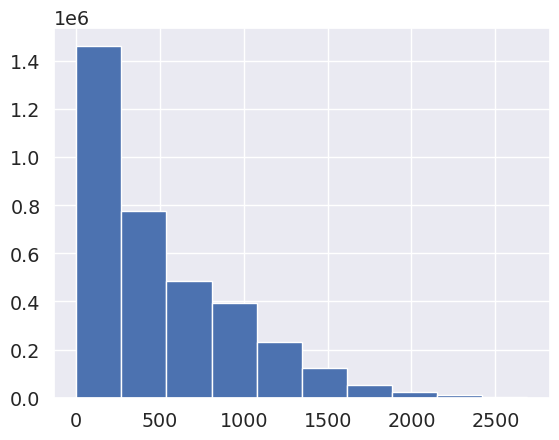

In [108]:
plt.hist(pred_grid['Pred_usable_conns2'])
plt.show()

In [ ]:
# test = pred_grid[pred_grid['Pred_usable_conns2'] < 120]['Pred_usable_conns2']
# test.head()

In [ ]:
# plt.hist(pred_grid[pred_grid['Pred_usable_conns2'] > 200.0]['Pred_usable_conns2'])
# plt.show()

In [109]:
pred_grid.sort_values(by='Pred_usable_conns2', ascending=False, inplace = True)

In [110]:
pred_grid.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,Lower,Upper,Pred_usable_conns2_Err
3538108,25,128,56,11,110,40,0.9,2689.515,2310.80128,3172.622628,169.056988
3540748,25,128,64,11,110,40,0.9,2685.776,2307.06228,3168.883628,169.156512
3543388,25,128,72,11,110,40,0.9,2676.791,2298.07728,3159.898628,114.204912
3487958,25,120,24,11,110,50,0.9,2674.002,2295.28828,3157.109628,84.480792
3538109,25,128,56,11,110,40,1.0,2673.566,2294.85228,3156.673628,106.542132
